In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import joblib
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [51]:
heart_dataset = pd.read_csv("heart.csv")
print("First 5 rows of dataset:")
print(heart_dataset.head())



First 5 rows of dataset:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [55]:
# -------------------------------
# Fix only unrealistic zero values
# -------------------------------

cols = ['trestbps','chol','thalach']

for col in cols:
    heart_dataset[col] = heart_dataset[col].replace(0, np.nan)
    heart_dataset[col].fillna(heart_dataset[col].median(), inplace=True)

In [57]:
print(heart_dataset["target"].value_counts())

target
1    165
0    138
Name: count, dtype: int64


In [44]:
# Split features and target
X = heart_dataset.drop(columns="target", axis=1)
Y = heart_dataset["target"]

In [21]:
# -------------------------------
# Stratified Split (IMPORTANT)
# -------------------------------
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=42
)

In [22]:
# Basic information
print("Shape of dataset:", heart_dataset.shape)

Shape of dataset: (303, 14)


In [46]:
print("\nTarget Value Counts:")
print(heart_dataset["target"].value_counts())


Target Value Counts:
target
1.0    303
Name: count, dtype: int64


In [25]:
print("\nGroupby Outcome Mean:")
print(heart_dataset.groupby("target").mean())


Groupby Outcome Mean:
              age  sex        cp    trestbps        chol  fbs   restecg  \
target                                                                    
1.0     54.366337  1.0  1.910891  131.623762  246.264026  1.0  1.013201   

           thalach  exang  oldpeak     slope        ca      thal  
target                                                            
1.0     149.646865    1.0  1.49703  1.537954  1.306931  2.326733  


In [37]:
# -------------------------------
# Feature Scaling
# -------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

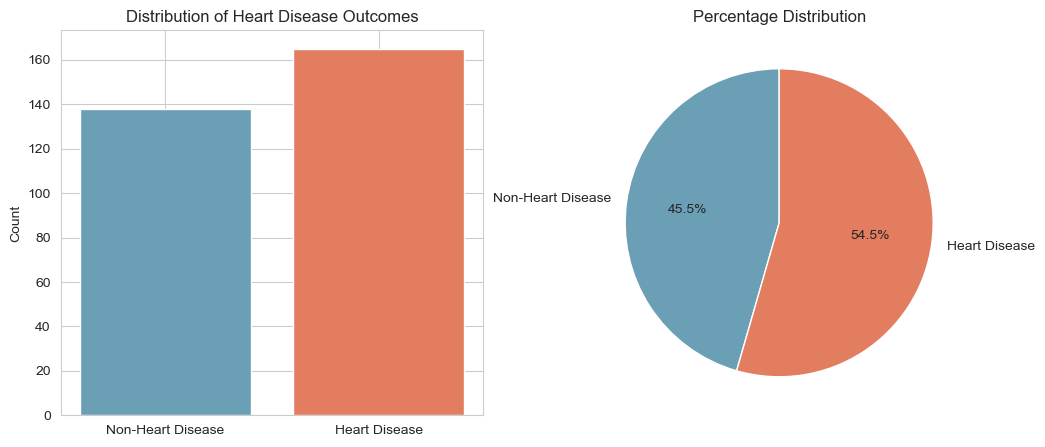

In [58]:
outcome_counts = heart_dataset["target"].value_counts().sort_index()

plt.figure(figsize=(12,5))

# Bar chart
plt.subplot(1,2,1)
plt.bar(
    ['Non-Heart Disease','Heart Disease'],
    outcome_counts.values,
    color=['#6A9FB5','#E27D60']
)
plt.title("Distribution of Heart Disease Outcomes")
plt.ylabel("Count")

# Pie chart
plt.subplot(1,2,2)
plt.pie(
    outcome_counts.values,
    labels=['Non-Heart Disease','Heart Disease'],
    autopct='%1.1f%%',
    colors=['#6A9FB5','#E27D60'],
    startangle=90
)
plt.title("Percentage Distribution")

plt.show()

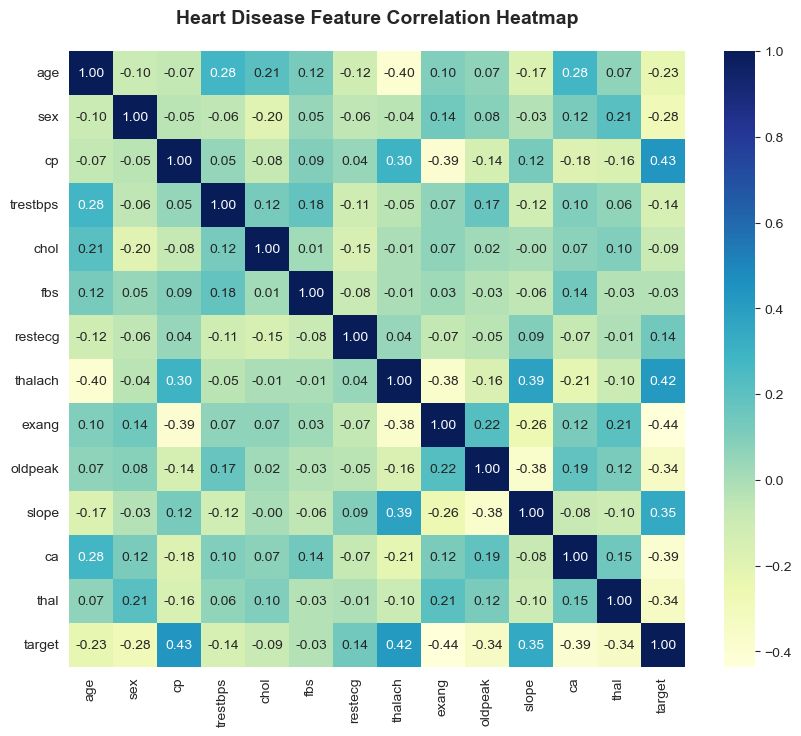

In [60]:
# Plotting correlation heatmap of features (Heart Disease Dataset)

plt.figure(figsize=(10, 8))  # set figure size

# Compute correlation matrix
correlation = heart_dataset.corr()

# Create heatmap
sns.heatmap(
    correlation,        # correlation data
    annot=True,         # show numbers in cells
    cmap='YlGnBu',      # different color map (yellow-green-blue)
    square=True,        # square cells
    fmt='.2f'           # show values with 2 decimal places
)

# Add title
plt.title('Heart Disease Feature Correlation Heatmap', fontsize=14, pad=20, fontweight='bold')

# Show plot
plt.show()

In [61]:
# Split the dataset into features (X) and target (Y)

X = heart_dataset.drop(columns='target', axis=1)  # Features: all columns except 'target'
Y = heart_dataset['target']  # Target variable

# Display the features and target
print("Features (X):")
print(X.head())   # Show first 5 rows of features

print("\nTarget (Y):")
print(Y.head())   # Show first 5 rows of target

Features (X):
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  
0   0     1  
1   0     2  
2   0     2  
3   0     2  
4   0     2  

Target (Y):
0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64


In [65]:
# Convert scaled data back to DataFrame for better visualization
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled Feature Data:")
print(X_scaled.head())

Scaled Feature Data:
        age       sex        cp  trestbps      chol       fbs   restecg  \
0  0.952197  0.681005  1.973123  0.763956 -0.256334  2.394438 -1.005832   
1 -1.915313  0.681005  1.002577 -0.092738  0.072199 -0.417635  0.898962   
2 -1.474158 -1.468418  0.032031 -0.092738 -0.816773 -0.417635 -1.005832   
3  0.180175  0.681005  0.032031 -0.663867 -0.198357 -0.417635  0.898962   
4  0.290464 -1.468418 -0.938515 -0.663867  2.082050 -0.417635  0.898962   

    thalach     exang   oldpeak     slope        ca      thal  
0  0.015443 -0.696631  0.884728 -2.274579 -0.714429 -2.148873  
1  1.633471 -0.696631  2.206910 -2.274579 -0.714429 -0.512922  
2  0.977514 -0.696631 -0.106909  0.976352 -0.714429 -0.512922  
3  1.239897 -0.696631 -0.768000  0.976352 -0.714429 -0.512922  
4  0.583939  1.435481 -0.988364  0.976352 -0.714429 -0.512922  


In [66]:
# Use scaled features for ML
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled,       # Use scaled features
    Y,              # Target
    test_size=0.2,  # 20% data for testing
    stratify=Y,     # Maintain proportion of classes
    random_state=2  # For reproducibility
)

# Print shapes of training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape: ", Y_test.shape)


# -------- Random Forest Classifier --------
rf_model = RandomForestClassifier(
    n_estimators=500,   # number of trees
    random_state=42
)

# Train the model
rf_model.fit(X_train, Y_train)

# Print confirmation
print("\nRandom Forest model trained successfully!")

X_train shape: (242, 13)
X_test shape:  (61, 13)
Y_train shape: (242,)
Y_test shape:  (61,)

Random Forest model trained successfully!


In [67]:
# Prediction on test data
x_test_prediction = rf_model.predict(X_test)

# Accuracy
test_data_accuracy = accuracy_score(Y_test, x_test_prediction)
print("Test Accuracy:", test_data_accuracy)

# Other evaluation metrics
precision = precision_score(Y_test, x_test_prediction)
recall = recall_score(Y_test, x_test_prediction)
f1 = f1_score(Y_test, x_test_prediction)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Test Accuracy: 0.7704918032786885
Precision: 0.8064516129032258
Recall: 0.7575757575757576
F1 Score: 0.78125


In [68]:
# Create Gradient Boosting model
# n_estimators → number of boosting stages
# learning_rate → controls contribution of each tree
# max_depth → limits tree depth to avoid overfitting

gb_classifier = GradientBoostingClassifier(
    n_estimators=200,     # number of boosting stages
    learning_rate=0.05,   # smaller learning rate improves generalization
    max_depth=3,          # shallow trees work well for boosting
    random_state=42
)

# Train the model on training data
# X_train → input features for training
# Y_train → actual labels for training

gb_classifier.fit(X_train, Y_train)

# Confirmation
print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [69]:
# Predict on test data
gb_predictions = gb_classifier.predict(X_test)

# Calculate accuracy of Gradient Boosting model
gb_accuracy = accuracy_score(Y_test, gb_predictions)
print("Gradient Boosting Accuracy:", gb_accuracy)

# Other evaluation metrics
gb_precision = precision_score(Y_test, gb_predictions)  # How many predicted heart disease cases are actually correct
gb_recall = recall_score(Y_test, gb_predictions)        # How many actual heart disease cases were detected
gb_f1 = f1_score(Y_test, gb_predictions)                 # Harmonic mean of precision and recall

print("Precision:", gb_precision)
print("Recall:", gb_recall)
print("F1 Score:", gb_f1)

Gradient Boosting Accuracy: 0.7868852459016393
Precision: 0.8125
Recall: 0.7878787878787878
F1 Score: 0.8


[[22  6]
 [ 7 26]]


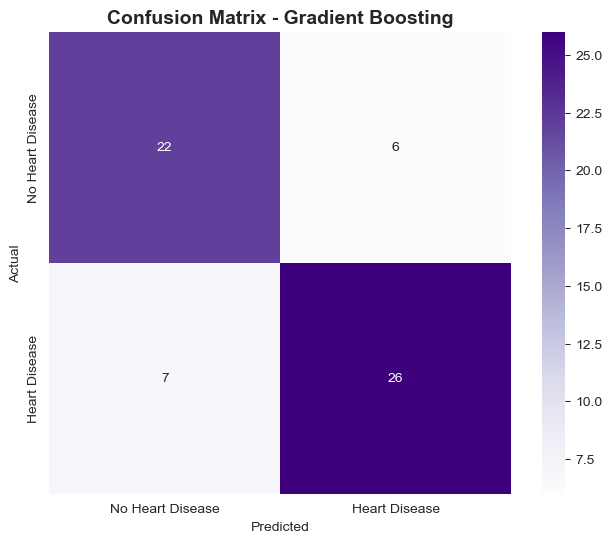

In [70]:
# Confusion Matrix
cm_gb = confusion_matrix(Y_test, gb_predictions)
print(cm_gb)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_gb,
    annot=True,              # Show numbers in cells
    fmt='d',                 # Integer format
    cmap='Purples',          # Different color theme
    square=True,             # Square cells
    xticklabels=['No Heart Disease', 'Heart Disease'],
    yticklabels=['No Heart Disease', 'Heart Disease']
)

plt.title('Confusion Matrix - Gradient Boosting', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

In [75]:
# -----------------------------
# Compare Random Forest vs Gradient Boosting
# -----------------------------

# Print Random Forest test accuracy
print("Random Forest Test Accuracy:",test_data_accuracy)

# Print Gradient Boosting test accuracy
print("Gradient Boosting Test Accuracy:", gb_accuracy)

Random Forest Test Accuracy: 0.7704918032786885
Gradient Boosting Test Accuracy: 0.7868852459016393


In [76]:
# Save trained Gradient Boosting model
joblib.dump(gb_classifier, 'heart_disease_model.pkl')

# Save scaler
joblib.dump(scaler, 'heart_scaler.pkl')

print("Heart disease model and scaler saved successfully!")

Heart disease model and scaler saved successfully!


In [77]:
# -----------------------------
# Predict Heart Disease for New Patient
# -----------------------------

# Input data for a single patient
# Order of features must match training data:
# age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal

input_data = (52, 1, 0, 125, 212, 0, 1, 168, 0, 1.0, 2, 2, 3)

# Convert tuple to NumPy array
input_num_array = np.asarray(input_data)

# Reshape to 2D array (1 row, 13 features)
reshape = input_num_array.reshape(1, -1)

# Scale the input data using the same scaler used during training
std_data = scaler.transform(reshape)

# Make prediction using Gradient Boosting model
prediction = gb_classifier.predict(std_data)

# Print human-readable result
if prediction[0] == 0:
    print("Prediction: Patient has No Heart Disease")
else:
    print("Prediction: Patient has Heart Disease")

Prediction: Patient has No Heart Disease
